## HateXplain - 7 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual
* **Target 4:** Hate speech against indigenous
* **Target 5:** Hate speech against african
* **Target 6:** Hate speech against asian
* **Target 7:** Hate speech against jewish

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo
from ml_moo import get_objectives, get_models
from ml_moo.analysis.visualization import plot_parallel_coordinates
from ml_moo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:
task_config = {
    "hate_speech": {"type": "hate_speech"},
    "women_hate": {"type": "group_hate", "group": "Women"},
    "homosexual_hate": {"type": "group_hate", "group": "Homosexual"},
    "indigenous_hate": {"type": "group_hate", "group": "Indigenous"},
    "african_hate": {"type": "group_hate", "group": "African"},
    "asian_hate": {"type": "group_hate", "group": "Asian"},
    "jewish_hate": {"type": "group_hate", "group": "Jewish"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:46<00:00, 10.24it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

In [9]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

23:11:33 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
23:11:33 | DEBUG | ml_moo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 93.88it/s]


Epoch 1 - Average loss: 0.1049


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 98.01it/s] 


Epoch 2 - Average loss: 0.1024


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 91.30it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 92.09it/s]


Epoch 2 - Average loss: 0.0870


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 91.00it/s]


Epoch 3 - Average loss: 0.0873


KeyboardInterrupt: 

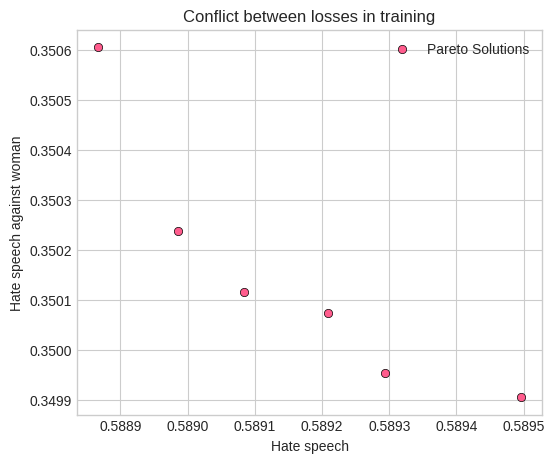

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_parallel_coordinates(objectives=objs, 
                          labels=tuple(task_names), 
                          title=title,
                          #point = equal.objs,
                          color="#FF5C8D"
                        )

11:37:18 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
11:37:18 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 140.46it/s]


Epoch 1 - Average training loss: 0.3525


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:01<00:00, 139.16it/s]


...

Epoch 2 - Average training loss: 0.2456


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 120.43it/s]


Epoch 3 - Average training loss: 0.2450


Evaluating: 100%|██████████| 241/241 [00:01<00:00, 147.31it/s]
11:43:33 | DEBUG | ml_moo | Calculated weights: [0.51293175 0.48706825]
11:43:33 | DEBUG | ml_moo | Importance: 9.674870269221758e-05
11:43:33 | DEBUG | ml_moo | Global lower bound (y*): [0.58917651 0.34985725]
11:43:33 | DEBUG | ml_moo | Iteration 51
11:43:33 | DEBUG | ml_moo | Solutions list: [array([0.58918806, 0.3503525 ]), array([0.58962123, 0.34985725]), array([0.58939487, 0.34998208]), array([0.58921405, 0.3501725 ]), array([0.58917651, 0.35050325]), array([0.58944072, 0.34994687])]


new solution dominated [0.58932878 0.35051752]


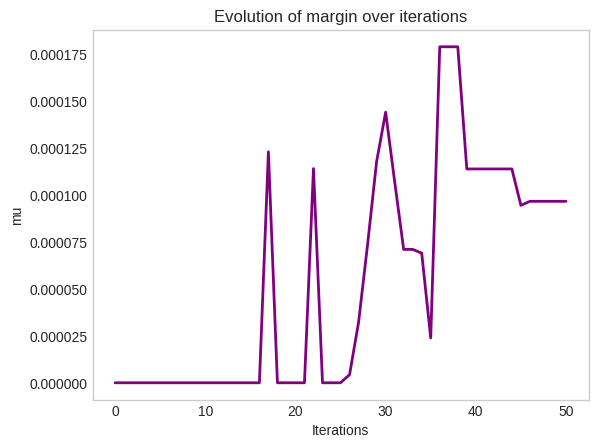

11:43:33 | INFO | ml_moo | Fit runtime: 375.04 seconds


In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

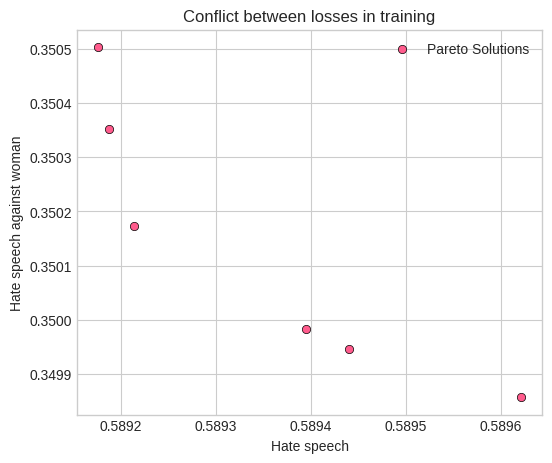

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_parallel_coordinates(objectives=objs, 
                          labels=tuple(task_names), 
                          title=title,
                          #point = equal.objs,
                          color="#FF5C8D"
                        )

### Random Weight

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [ ]:
from ml_moo.analysis.moo_analyzer import Analyzer

11:53:02 | WARNING | ml_moo | [Methods have different numbers of solutions: {50, 6}


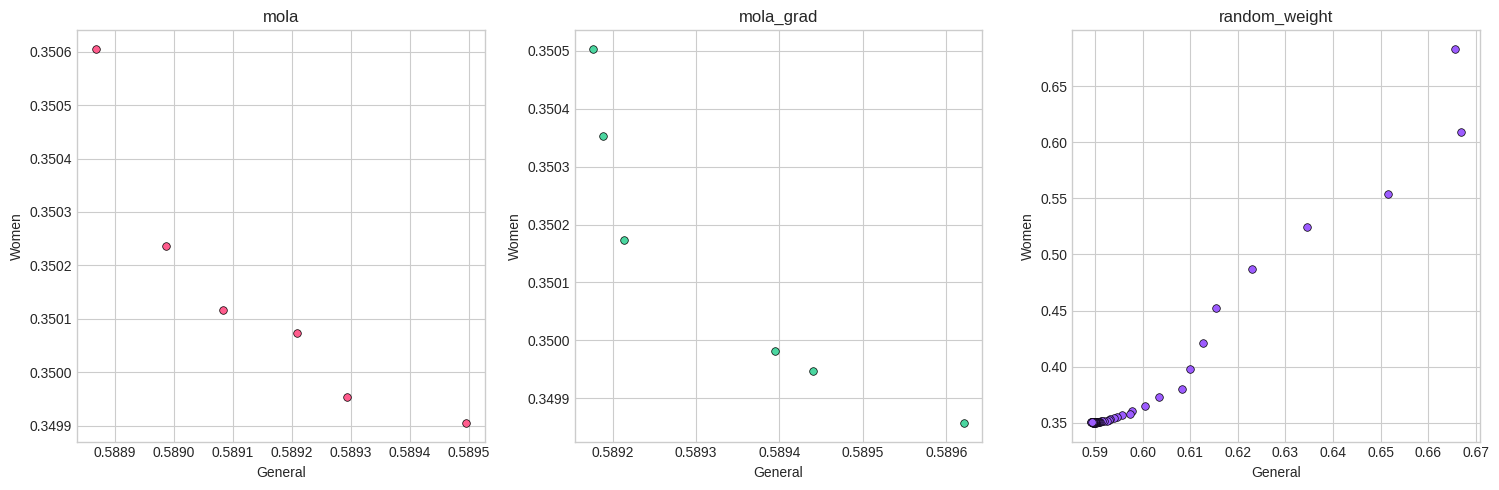

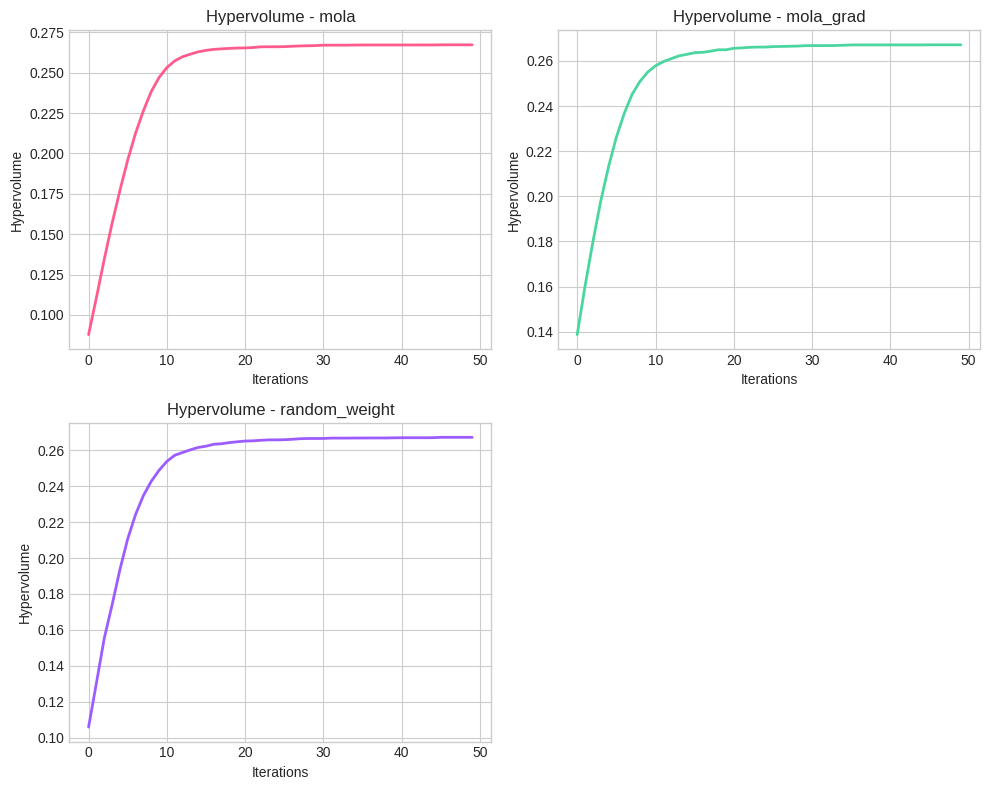

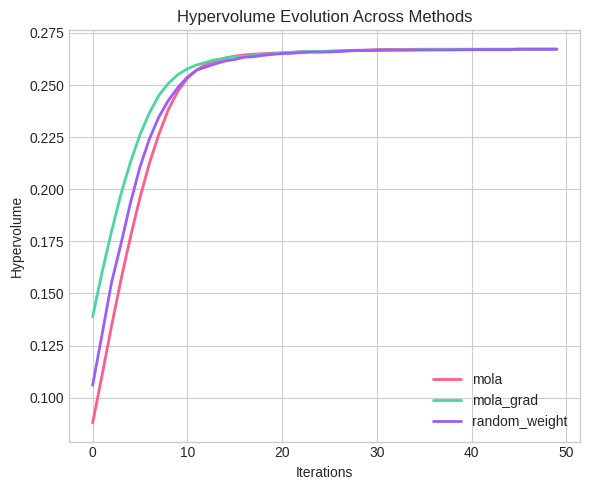

[Analyzer] Visualization complete.


In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = task_names
Analyzer.run_multiple(
                      pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = False, 
                      show_hypervolume = True,
                      show_parallel=True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      axis_label=axis_label
                      )

In [ ]:
from ml_moo.analysis.visualization import plot_pareto_2d_set_limit

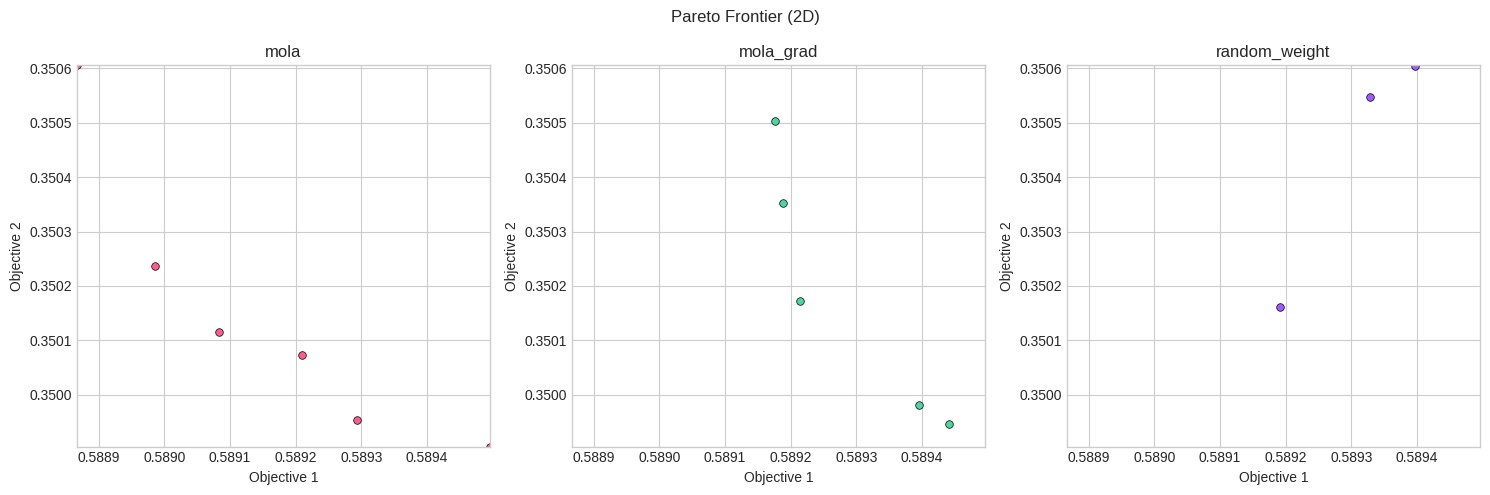

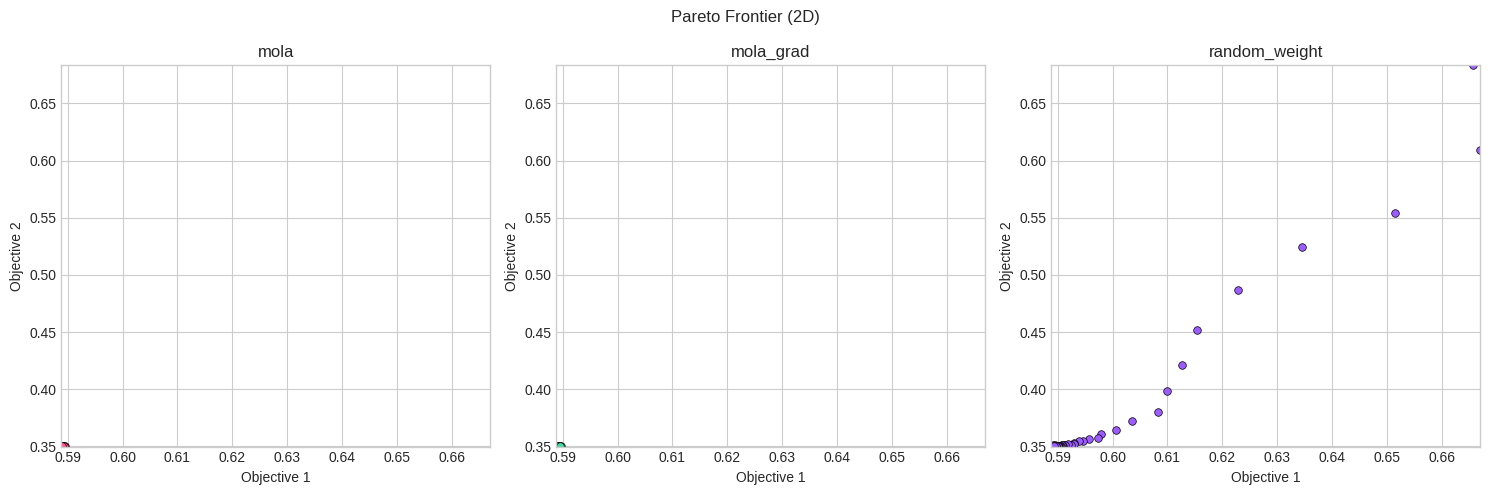

In [ ]:
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="first")
plot_pareto_2d_set_limit(pareto_dict, colors=colors_hv, axis_mode="global") 